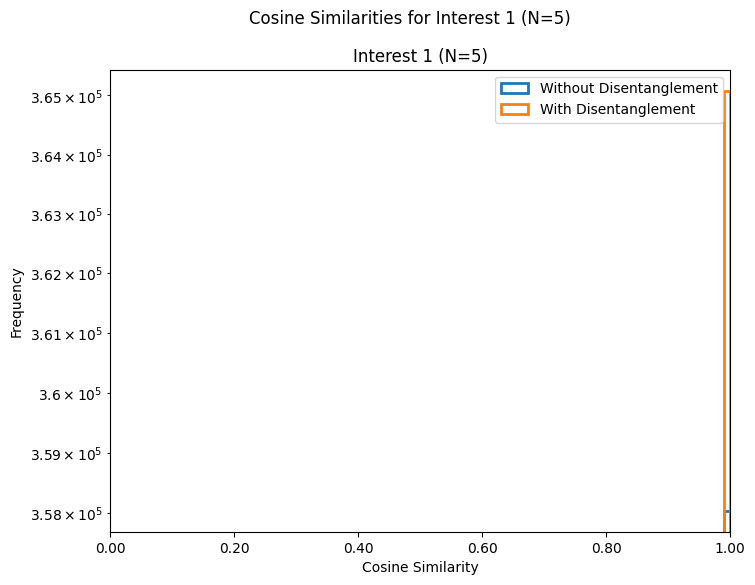

Saved plot for Interest 1 at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/comparison_plots_per_interest/cosine_similarities_interest_1_N5.png


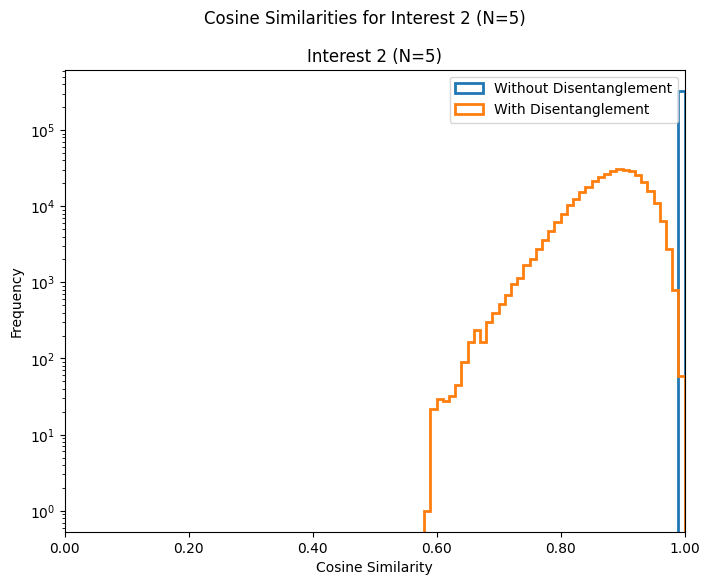

Saved plot for Interest 2 at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/comparison_plots_per_interest/cosine_similarities_interest_2_N5.png


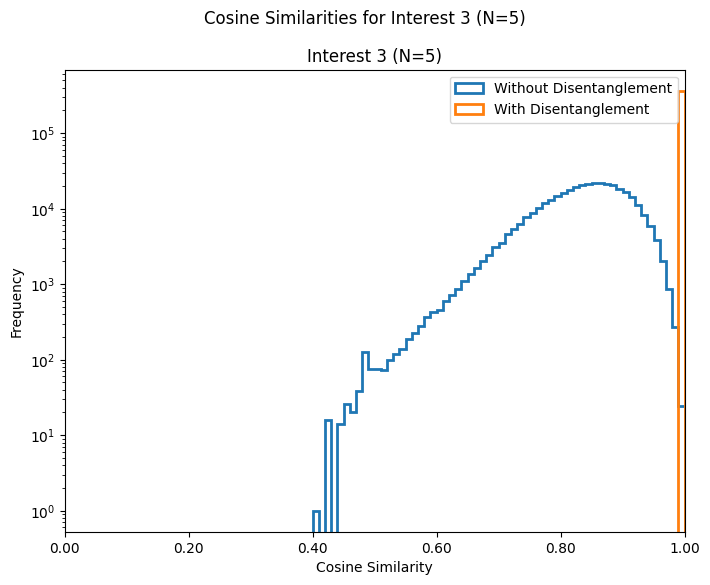

Saved plot for Interest 3 at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/comparison_plots_per_interest/cosine_similarities_interest_3_N5.png


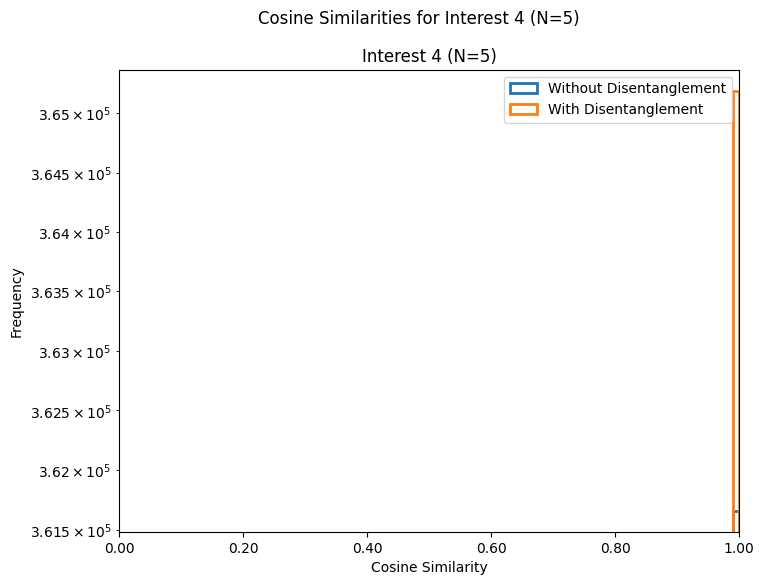

Saved plot for Interest 4 at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/comparison_plots_per_interest/cosine_similarities_interest_4_N5.png


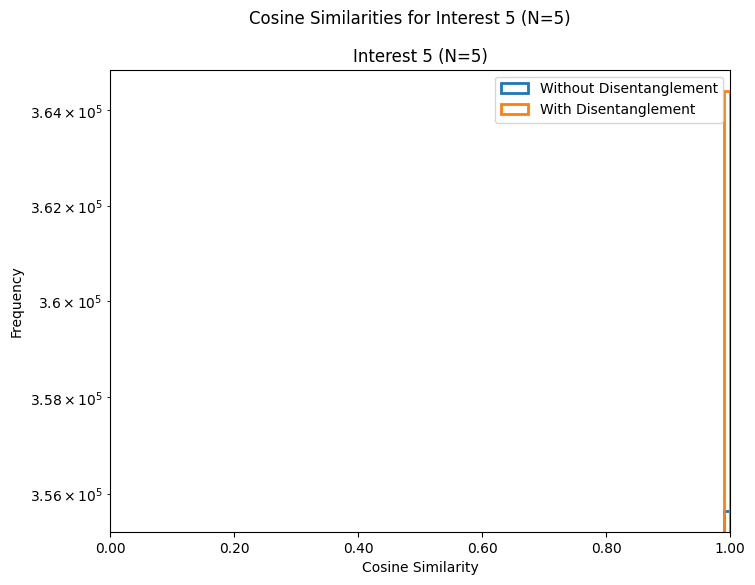

Saved plot for Interest 5 at /mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/comparison_plots_per_interest/cosine_similarities_interest_5_N5.png


In [3]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def plot_cosine_similarities_histogram(ax, cos_similarities, title, xlabel, ylabel, log_scale=False):
    """
    Plot a histogram of cosine similarities on the provided axis using 'step' histtype for more detailed visualization.

    Args:
        ax (matplotlib.axes.Axes): The axis on which to plot the histogram.
        cos_similarities (list): List of cosine similarities to plot.
        title (str): Title of the histogram.
        xlabel (str): Label for the x-axis.
        ylabel (str): Label for the y-axis.
        log_scale (bool): Whether to plot the histogram on a logarithmic scale. Default is False.
    """
    # Ensure the cosine similarities are between 0 and 1
    filtered_cos_similarities = [cs for cs in cos_similarities if 0.0 <= cs <= 1.0]

    ax.hist(filtered_cos_similarities, bins=100, histtype='step', linewidth=2, log=log_scale, range=(0.0, 1.0))
    ax.set_xlim(0.0, 1.0)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    # Formatting x-axis to ensure we see 0.0, 0.2, ... 1.0
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))

def compute_cosine_similarities_per_interest(user_representations):
    """
    Compute cosine similarities for each interest group against the mean representation.

    Args:
        user_representations (np.ndarray): Array of user representations (users x interests x features).

    Returns:
        dict: Cosine similarities for each interest group.
    """
    num_interests = user_representations.shape[1]
    cos_similarities_per_interest = {}

    # Compute the mean representation across all users for each interest
    mean_representation_all = np.mean(user_representations, axis=0)

    for interest_idx in range(num_interests):
        interest_representations = user_representations[:, interest_idx, :]
        mean_representation = mean_representation_all[interest_idx]

        # Calculate cosine similarities for this interest
        cos_similarities = np.sum(interest_representations * mean_representation, axis=1) / (
                np.linalg.norm(interest_representations, axis=1) * np.linalg.norm(mean_representation))
        
        cos_similarities_per_interest[interest_idx] = cos_similarities

    return cos_similarities_per_interest

def plot_histograms_per_interest(pickle_file_path_without_disentanglement, pickle_file_path_with_disentanglement, N_value, save_dir):
    """
    Load user representations from two pickle files (with and without disentanglement),
    and plot separate histograms for each interest group comparing the two.

    Args:
        pickle_file_path_without_disentanglement (str): Path to the pickle file without disentanglement.
        pickle_file_path_with_disentanglement (str): Path to the pickle file with disentanglement.
        N_value (int): The value of N for the experiment (5, 10, etc.).
        save_dir (str): Directory to save the plots.
    """
    os.makedirs(save_dir, exist_ok=True)

    # Load user representations without disentanglement
    with open(pickle_file_path_without_disentanglement, 'rb') as f:
        user_representations_without = pickle.load(f)
    if not isinstance(user_representations_without, np.ndarray):
        user_representations_without = np.array(user_representations_without)

    # Load user representations with disentanglement
    with open(pickle_file_path_with_disentanglement, 'rb') as f:
        user_representations_with = pickle.load(f)
    if not isinstance(user_representations_with, np.ndarray):
        user_representations_with = np.array(user_representations_with)

    # Get cosine similarities per interest group
    cos_similarities_without = compute_cosine_similarities_per_interest(user_representations_without)
    cos_similarities_with = compute_cosine_similarities_per_interest(user_representations_with)

    # Get the number of interest groups
    num_interests = user_representations_without.shape[1]

    # Plot separate histograms for each interest group
    for interest_idx in range(num_interests):
        fig, ax = plt.subplots(figsize=(8, 6))

        # Plot histogram for "without disentanglement"
        plot_cosine_similarities_histogram(
            ax,
            cos_similarities_without[interest_idx],
            title=f'Interest {interest_idx+1} (N={N_value})',
            xlabel='Cosine Similarity',
            ylabel='Frequency',
            log_scale=True
        )

        # Plot histogram for "with disentanglement" on the same axis
        plot_cosine_similarities_histogram(
            ax,
            cos_similarities_with[interest_idx],
            title=f'Interest {interest_idx+1} (N={N_value})',
            xlabel='Cosine Similarity',
            ylabel='Frequency',
            log_scale=True
        )

        plt.legend(['Without Disentanglement', 'With Disentanglement'])
        plt.suptitle(f'Cosine Similarities for Interest {interest_idx+1} (N={N_value})')

        # Save the plot
        plot_path = os.path.join(save_dir, f'cosine_similarities_interest_{interest_idx+1}_N{N_value}.png')
        plt.savefig(plot_path)
        plt.show()
        plt.close()
        print(f'Saved plot for Interest {interest_idx+1} at {plot_path}')

# Example usage for N=5
plot_histograms_per_interest(
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_user_representations/user_representations.pkl',
    '/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/experiments/MI_N5_dis_cos_bce_lamda_s_0.9/user_representations.pkl',
    N_value=5,
    save_dir='/mount/arbeitsdaten/tcl/tclext/godbolai/codethesis/nrs/comparison_plots_per_interest'
)
